In [7]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.4 MB/s eta 0:00:16
   - -------------------------------------- 2.6/101.7 MB 8.1 MB/s eta 0:00:13
   - -------------------------------------- 4.2/101.7 MB 7.5 MB/s eta 0:00:14
   -- ------------------------------------- 5.5/101.7 MB 7.1 MB/s eta 0:00:14
   -- ------------------------------------- 6.3/101.7 MB 6.8 MB/s eta 0:00:15
   -- ------------------------------------- 7.1/101.7 MB 6.0 MB/s eta 0:00:16
   -- ------------------------------------- 7.6/101.7 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 7.9/101.7 MB 5.5 MB/s eta 0:00:17
   --- ------------------------------------ 8.9/101.7 MB 5.0 MB/s eta 0:00:19
   ---- ----------------------------------- 10.2/101.7 MB 5.0 MB/s eta 0:00:19
   ---- ----------------------------------- 11.5/101.7 MB 5.1 MB/s eta 0:00:18
   ---- ----------------------------------- 12.6/101.7 MB 5.1 MB/s et

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS =set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
#load the data
data=pd.read_csv(r"amazon_alexa.tsv",delimiter='\t',quoting=3)
print(f"Dataset shape : {data.shape}")

Dataset shape : (3150, 5)


In [14]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [15]:
#column names
print(f"Feature names :{data.columns.values}")

Feature names :['rating' 'date' 'variation' 'verified_reviews' 'feedback']


In [16]:
#check null values
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [17]:
#getting the record where 'verifired_reviews' is null
data[data['verified_reviews'].isna()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [18]:
#we will drop the null record 
data.dropna(inplace=True)

In [19]:
print(f"Dataset shape after dropping null values : {data.shape}")

Dataset shape after dropping null values : (3149, 5)


In [20]:
#creating a new column 'length' that will contain the length of the string in 'verified_reviews' column
data['length']=data['verified_reviews'].apply(len)

In [21]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [22]:
#rondomly check for 10th record
print(f"'verified_records' column value : {data.iloc[10]['verified_reviews']}")  #original value
print(f"length of review : {len(data.iloc[10]['verified_reviews'])}") #length of review using len()
print(f"'length' column vale : {data.iloc[10]['length']}") #value of the column 'length'

'verified_records' column value : "I sent it to my 85 year old Dad, and he talks to it constantly."
length of review : 65
'length' column vale : 65


#we can see that the length of reviews is the same as the value in the length column for the record



#Datatypes of the feature

In [23]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

#analyzing 'rating' column -- this column refers to the rating of the variation given by the user


In [25]:
#distinct values of 'rating' and its count
print(f"Rating value count : \n{data['rating'].value_counts()}")

Rating value count : 
rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


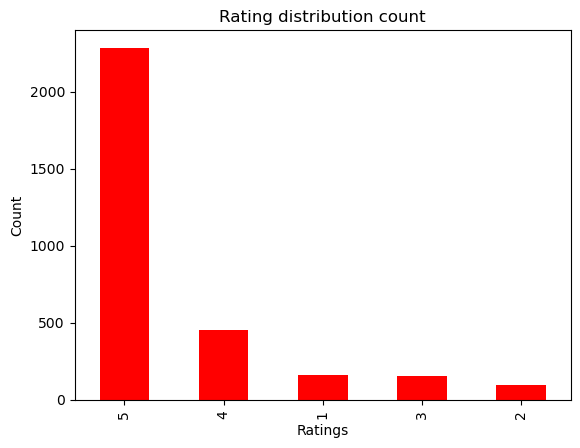

In [26]:
#bar graph to visualize the total counts of each ratings
data['rating'].value_counts().plot.bar(color ='red')
plt.title('Rating distribution count')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

In [27]:
#finding the percentage distribution of each rating -- we'll divide the number of records for each rating by total number of records
print(f"Rating value count - percentage disribution \n{round(data['rating'].value_counts()/data.shape[0]*100,2)}")

Rating value count - percentage disribution 
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


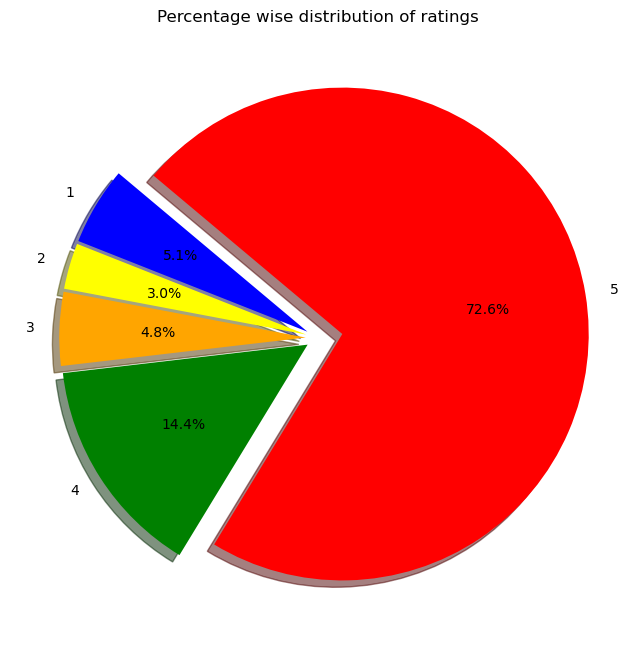

In [29]:


# Count ratings
rating_counts = data['rating'].value_counts().sort_index()

# Labels (ratings)
labels = rating_counts.index

# Sizes
sizes = rating_counts.values

# Explode effect (separate slices)
explode = [0.05, 0.05, 0.05, 0.05, 0.1]

# Colors (similar to image)
colors = ['blue', 'yellow', 'orange', 'green', 'red']

# Plot pie chart
plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    colors=colors,
    shadow=True,
    startangle=140
)

plt.title("Percentage wise distribution of ratings")

plt.show()

analyzing the 'feedback' column

In [30]:
#this column refers to the feedback of the verified review
#distinct values of 'feedback' and its count
print(f"Feedback value count : \n{data['feedback'].value_counts()}")

Feedback value count : 
feedback
1    2893
0     256
Name: count, dtype: int64


In [31]:
#extracting the 'verified_reviews' value for one record with feedback =0 
review_0=data[data['feedback']==0].iloc[1]['verified_reviews']
print(review_0)

Sound is terrible if u want good music too get a bose


In [32]:
#extracting the 'verified_reviews' value for one record with feedback =1
review_1=data[data['feedback']==1].iloc[1]['verified_reviews']
print(review_1)

Loved it!


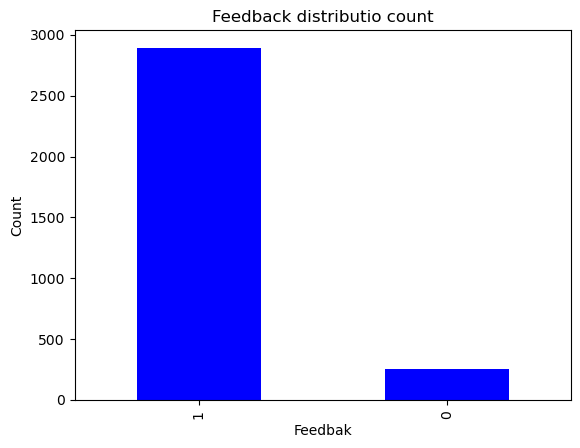

In [33]:
#bargraph to visualize the total counts of each feedback
data['feedback'].value_counts().plot.bar(color='blue')
plt.title('Feedback distributio count')
plt.xlabel('Feedbak')
plt.ylabel('Count')
plt.show()

In [34]:
#finding the percentage distribution of each feedback -- we'll divide the number of records for each feedback by total number of records
print(f"Feedback value count - percentage disribution \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value count - percentage disribution 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


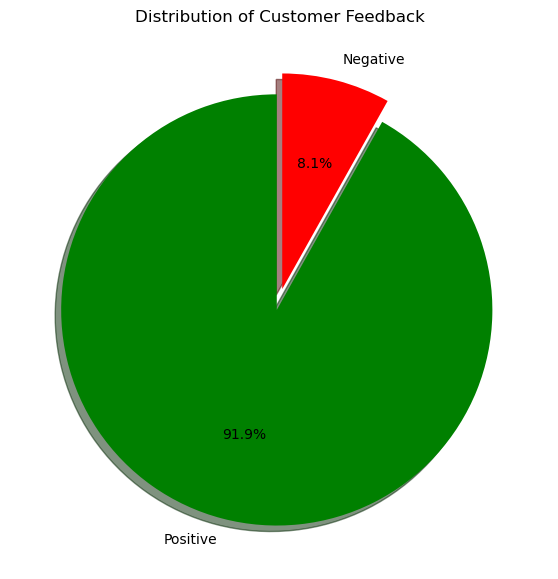

In [36]:

# Count feedback values
feedback_counts = data['feedback'].value_counts()

# Labels
labels = ['Positive', 'Negative']

# Sizes
sizes = feedback_counts.values

# Colors
colors = ['green', 'red']

# Explode effect
explode = (0.05, 0.05)

# Plot pie chart
plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    shadow=True,
    startangle=90
)

plt.title("Distribution of Customer Feedback")

plt.show()

In [38]:
data[data['feedback']==0]['rating'].value_counts() #feedback=0

rating
1    161
2     95
Name: count, dtype: int64

In [39]:
data[data['feedback']==1]['rating'].value_counts() #feedback=1

rating
5    2286
4     455
3     152
Name: count, dtype: int64

if rating of a review is 1 or 2 then the feeedback is negavtive- 0 and if the rating is 3,4 or 5 then the feedback is 1 positive

analyzing 'variation' column -- this coulmn refers to the variation or type of amazon alexa product. example - black dot, charcoal fabric etc

In [40]:
#distinct values of 'variation' and its count
print(f"Variation value count : \n{data['variation'].value_counts()}")

Variation value count : 
variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64


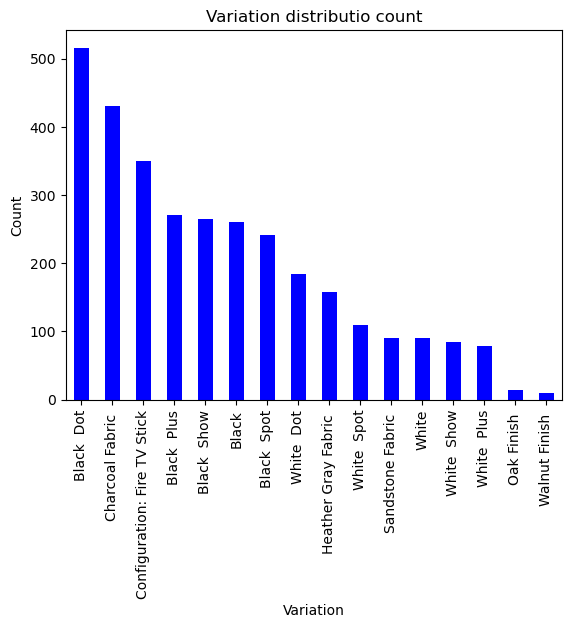

In [41]:
#bargraph to visualize the total counts of each variation
data['variation'].value_counts().plot.bar(color='blue')
plt.title('Variation distributio count')
plt.xlabel('Variation')
plt.ylabel('Count')
plt.show()

In [42]:
#finding the percentage distribution of each rating -- we'll divide the number of records for each rating by total number of records
print(f"Variation value count - percentage disribution \n{round(data['variation'].value_counts()/data.shape[0]*100,2)}")

Variation value count - percentage disribution 
variation
Black  Dot                      16.39
Charcoal Fabric                 13.66
Configuration: Fire TV Stick    11.11
Black  Plus                      8.57
Black  Show                      8.42
Black                            8.29
Black  Spot                      7.65
White  Dot                       5.84
Heather Gray Fabric              4.99
White  Spot                      3.46
Sandstone Fabric                 2.86
White                            2.86
White  Show                      2.70
White  Plus                      2.48
Oak Finish                       0.44
Walnut Finish                    0.29
Name: count, dtype: float64


MEAN RATING ACCORDING TO VARIATION

In [44]:
data.groupby('variation')['rating'].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.166667
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
Name: rating, dtype: float64

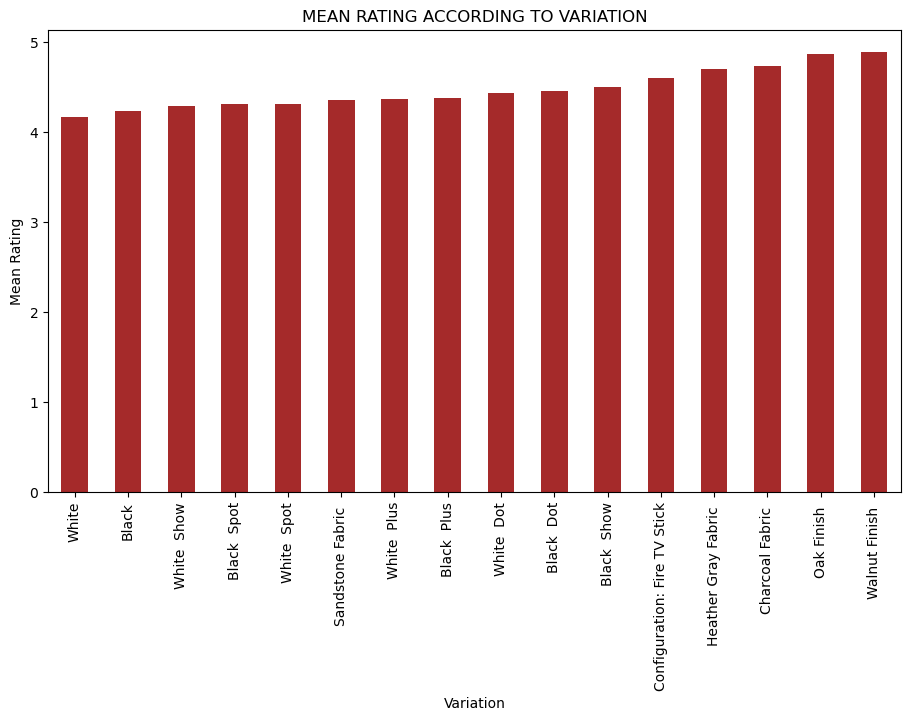

In [46]:
#lets analyze the above ratings
data.groupby('variation')['rating'].mean().sort_values().plot.bar(color='brown',figsize=(11,6))
plt.title('MEAN RATING ACCORDING TO VARIATION')
plt.xlabel('Variation')
plt.ylabel('Mean Rating')
plt.show()

Analyzing 'verified_reviews' column

In [47]:
data['length'].describe()

count    3149.000000
mean      132.714513
std       182.541531
min         1.000000
25%        30.000000
50%        74.000000
75%       166.000000
max      2853.000000
Name: length, dtype: float64

[Text(0.5, 1.0, 'Distribution of length of review')]

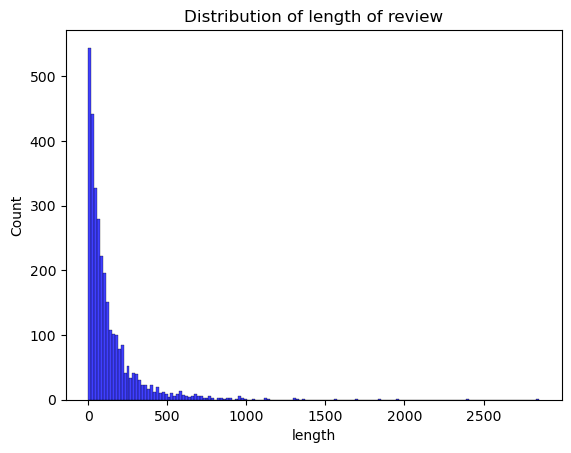

In [48]:
sns.histplot(data['length'],color='blue').set(title='Distribution of length of review')

[Text(0.5, 1.0, 'Distribution of length of review if feedback=0')]

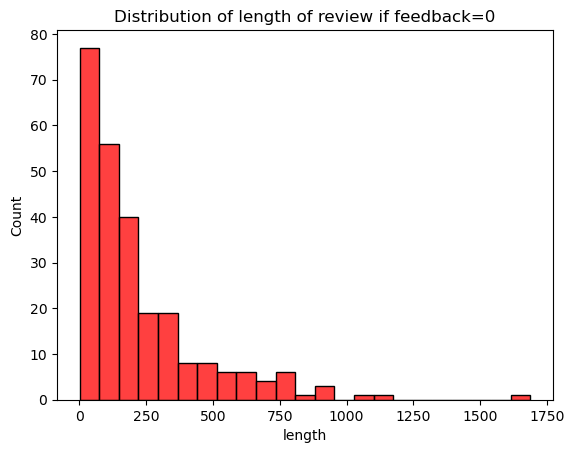

In [49]:
sns.histplot(data[data['feedback']==0]['length'],color='red').set(title='Distribution of length of review if feedback=0')

[Text(0.5, 1.0, 'Distribution of length of review if feedback=1')]

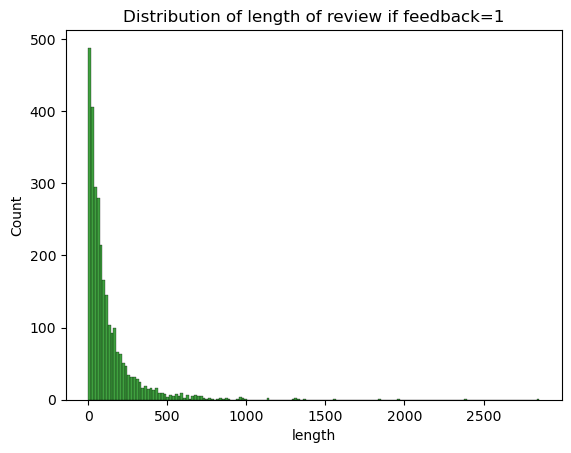

In [51]:
sns.histplot(data[data['feedback']==1]['length'],color='green').set(title='Distribution of length of review if feedback=1')

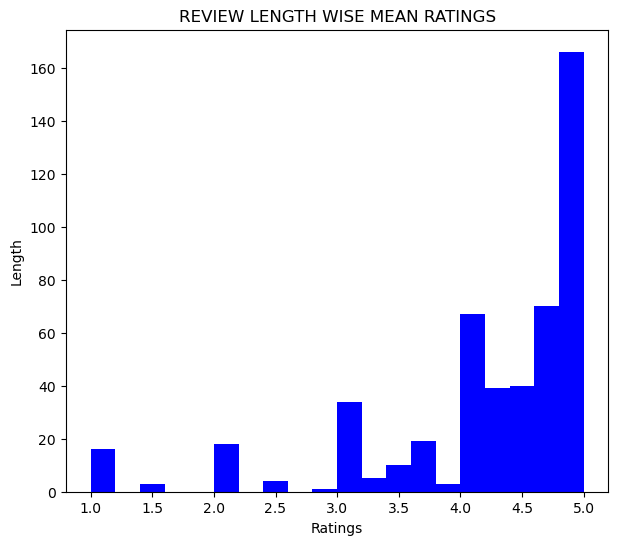

In [53]:
data.groupby('length')['rating'].mean().plot.hist(color='blue',figsize=(7,6),bins=20)
plt.title('REVIEW LENGTH WISE MEAN RATINGS')
plt.xlabel('Ratings')
plt.ylabel('Length')
plt.show()

In [54]:
cv=CountVectorizer(stop_words='english')
words=cv.fit_transform(data.verified_reviews)

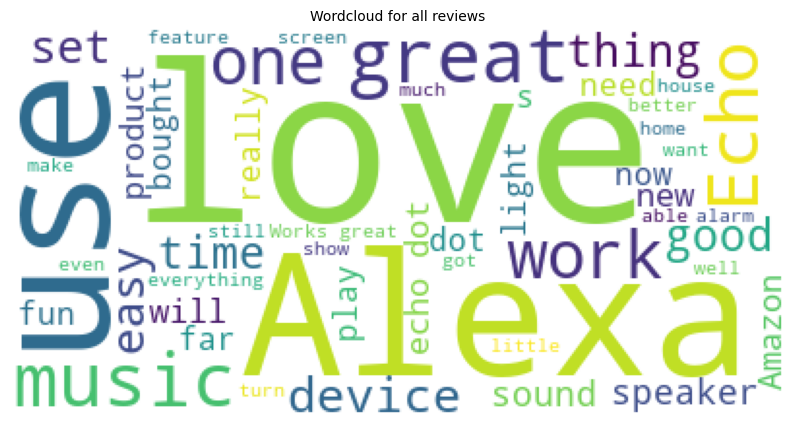

In [55]:
#combine all reviews
reviews=" ".join([review for review in data['verified_reviews']])

#initialize wordcloud object
wc=WordCloud(background_color='white',max_words=50)

#generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(reviews))
plt.title('Wordcloud for all reviews',fontsize=10)
plt.axis('off')
plt.show()


In [57]:

# Combine reviews based on feedback
positive_reviews = data[data['feedback'] == 1]['verified_reviews'].str.cat(sep=' ')
negative_reviews = data[data['feedback'] == 0]['verified_reviews'].str.cat(sep=' ')

# Split reviews into words
positive_words = positive_reviews.split()
negative_words = negative_reviews.split()

# Print sample
print("Positive words sample:", positive_words[:50])
print("Negative words sample:", negative_words[:50])

Positive words sample: ['Love', 'my', 'Echo!', 'Loved', 'it!', '"Sometimes', 'while', 'playing', 'a', 'game,', 'you', 'can', 'answer', 'a', 'question', 'correctly', 'but', 'Alexa', 'says', 'you', 'got', 'it', 'wrong', 'and', 'answers', 'the', 'same', 'as', 'you.', 'I', 'like', 'being', 'able', 'to', 'turn', 'lights', 'on', 'and', 'off', 'while', 'away', 'from', 'home."', '"I', 'have', 'had', 'a', 'lot', 'of', 'fun']
Negative words sample: ['"It\'s', 'like', 'Siri,', 'in', 'fact,', 'Siri', 'answers', 'more', 'accurately', 'then', 'Alexa.', 'I', "don't", 'see', 'a', 'real', 'need', 'for', 'it', 'in', 'my', 'household,', 'though', 'it', 'was', 'a', 'good', 'bargain', 'on', 'prime', 'day', 'deals."', 'Sound', 'is', 'terrible', 'if', 'u', 'want', 'good', 'music', 'too', 'get', 'a', 'bose', 'Not', 'much', 'features.', '"Stopped', 'working', 'after']


In [59]:
# Combine reviews for each feedback
positive_reviews = data[data['feedback'] == 1]['verified_reviews'].str.cat(sep=' ')
negative_reviews = data[data['feedback'] == 0]['verified_reviews'].str.cat(sep=' ')

# Split into words
positive_words = set(positive_reviews.lower().split())
negative_words = set(negative_reviews.lower().split())

# Words present only in positive feedback
positive_only_words = positive_words - negative_words

# Words present only in negative feedback
negative_only_words = negative_words - positive_words

# Print some examples
print("Positive only words sample:", list(positive_only_words)[:20])
print("Negative only words sample:", list(negative_only_words)[:20])

Positive only words sample: ['alexis', 'owning', 'alarms!', 'batman!', 'commands', 'al', 'shuts', 'huele', 'solely', 'satisified', 'tales', 'space', 'through.', 'louder,', 'lamps', 'smartbon', 'trainees', '&#34;alexa', 'mind', 'ones.']
Negative only words sample: ['refund', '"why', 'app...&#34;)', 'buzzing', 'reboot', 'along,', 'potential,', '&#34;cycle&#34;', 'contents,', 'fan...love', 'eh.', 'june', 'trending”.', 'featured', 'buld', '$600+', 'broke', '“alexa”."', 'glitching."', 'pre-set']


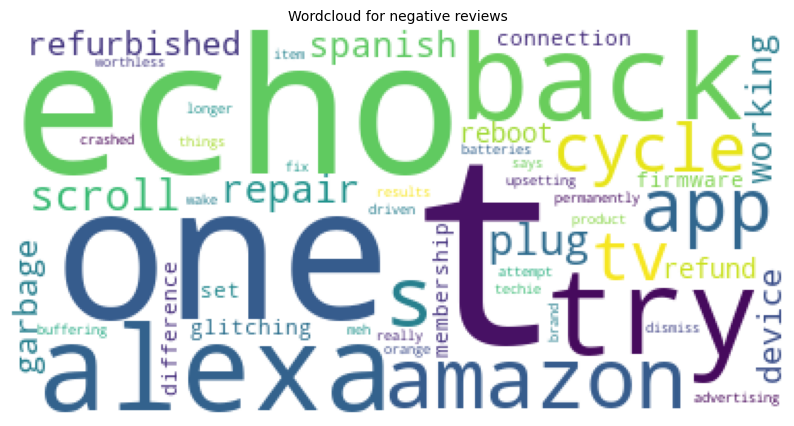

In [63]:
#initialize wordcloud object
unique_negative = " ".join(negative_words - positive_words)
wc=WordCloud(background_color='white',max_words=50)

#generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title('Wordcloud for negative reviews',fontsize=10)
plt.axis('off')
plt.show()

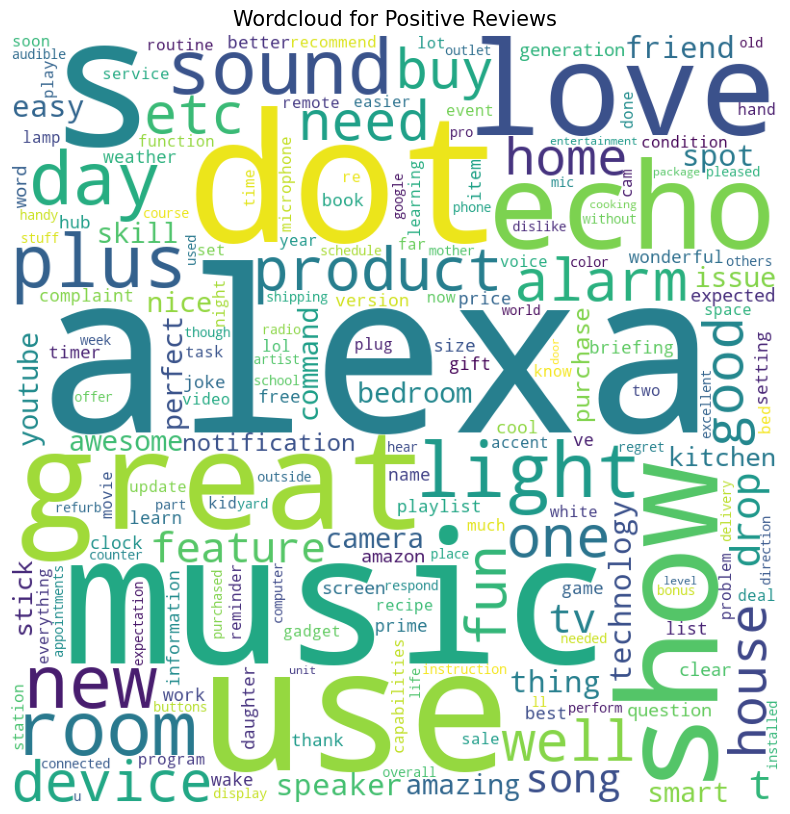

In [66]:
# Combine reviews
positive_reviews = data[data['feedback']==1]['verified_reviews'].str.cat(sep=' ')
negative_reviews = data[data['feedback']==0]['verified_reviews'].str.cat(sep=' ')

# Convert into sets of words
positive_words = set(positive_reviews.lower().split())
negative_words = set(negative_reviews.lower().split())

# Words only in positive reviews
unique_positive = " ".join(positive_words - negative_words)

# Create WordCloud
wc = WordCloud(width=800, height=800, background_color='white')

plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title('Wordcloud for Positive Reviews', fontsize=15)
plt.axis('off')
plt.show()